# Heatmaps

To better understand the patterns of expression across samples, I'm going to plot heatmaps of DEGs in pairwise comparisons using the outputs from [filter_deseq_p2.v.p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/filter_deseq_p2.v.p2.ipynb)

## 0. load libraries

In [2]:
library(tidyverse)
library(pheatmap)

## 1. load csvs

### a. DEGs

In [109]:
# get list of files
files <- list.files(
    path = '/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/DEGs/',
    pattern = '\\.csv$',
    full.names = TRUE
    )

# Read each CSV and extract the DEG column
deg_list <- lapply(files, function(f) {
    df <- read.csv(f)
    df$Gene
})

# Name each list element
names(deg_list) <- tools::file_path_sans_ext(basename(files))

# Remove DEG_ prefix
names(deg_list) <- sub("^DEG_", "", names(deg_list))

names(deg_list)

[1] "bb_cc"        "bc_bb"        "bc_cc"        "bc_hc"        "bc_wc"       
 [6] "bh_ch"        "bh_hh"        "bw_cw"        "bw_ww"        "cb_bb"       
[11] "cb_bc"        "cb_cc"        "cb_ch"        "cb_cw"        "ch_cc"       
[16] "ch_hc"        "cw_cc"        "cw_ch"        "cw_wc"        "hb_bb"       
[21] "hb_bh"        "hb_cb"        "hc_cc"        "hc_hh"        "hh_cc"       
[26] "hh_ch"        "vst_filtered" "wb_bb"        "wb_bw"        "wb_cb"       
[31] "wc_cc"        "wc_hc"        "wc_ww"        "wh_hw"        "ww_cc"       
[36] "ww_cw"

### b. vst
want a numeric matrix for `pheatmap`, with rows = genes and columns = samples

In [129]:
vst <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/deseq_res/prefilter_deseq/vst_filtered.csv') %>%
column_to_rownames('X')

dim(vst)
head(vst)

[1] 26060    92

,B1_B1_O01,B1_W5_O50,B2_B5_O51,B2_C4_O40,B3_B4_O41,B3_C3_O30,B3_C6_O66,B3_H4_O41,B3_W1_O06,B3_W4_O41,⋯,W4_W5_G56,W5_B2_G21,W5_C4_G45,W5_H4_G46,W5_W2_G22,W6_B3_G35,W6_B4_G48,W6_H6_G71,W6_W3_G36,W6_W4_G48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144621260,11.623469,11.423471,11.408838,11.275151,11.000572,10.984042,11.367711,11.063231,11.165032,11.186417,⋯,11.835304,10.661320,11.109093,11.545469,11.412500,11.239716,11.371961,11.224874,11.809569,11.656580
LOC144621269,9.029866,11.165142,11.566796,10.565749,11.604647,10.704805,12.821577,11.068945,8.822612,8.684961,⋯,13.912374,8.621367,8.691295,10.274234,8.968732,9.263748,13.469161,8.803617,9.970848,13.447100
LOC111120925,9.098889,8.848789,10.019625,8.719850,8.800497,8.700895,8.483578,8.561028,8.483578,8.559747,⋯,9.898177,8.483578,8.630520,10.036487,9.143250,8.897954,8.666530,8.563742,8.746574,8.719664
LOC144621283,10.155971,10.545362,10.566871,10.406314,10.492742,10.753400,10.721783,10.029620,10.340600,10.432119,⋯,10.240015,10.675777,10.441461,10.568882,10.541882,10.464685,10.218781,11.013852,10.231790,10.260001
LOC144621276,13.471496,13.514187,13.684737,13.520469,13.795151,13.915398,13.731482,13.241632,13.773795,13.454805,⋯,14.039092,13.330391,13.866055,13.565448,13.121654,13.302953,13.949750,13.395173,13.440389,13.391663
LOC111115920,9.429854,9.490282,9.402242,9.264949,9.195805,9.150586,9.071305,9.912396,9.234906,9.790446,⋯,9.168003,9.248230,9.651698,9.353947,9.937921,9.940522,9.492055,9.633900,9.216327,9.313269


### c. meta data

In [130]:
meta <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/metaData/sample_metaData.csv') %>%
# remove phase 1 samples
filter(Phase2_treatment != 'NA')

dim(meta)
head(meta)

[1] 96  9

,Sample,Phase1_treatment,Phase1_temp,Phase1_DO,Phase1_TankRep,Phase2_treatment,Phase2_temp,Phase2_DO,Phase2_TankRep
,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>
1,B1_B1_O01,both,warm,hypoxic,1,both,warm,hypoxic,1
2,B1_W5_O50,both,warm,hypoxic,1,warm,warm,normoxic,5
3,B2_B5_O51,both,warm,hypoxic,2,both,warm,hypoxic,5
4,B2_C4_O40,both,warm,hypoxic,2,control,ambient,normoxic,4
5,B3_B4_O41,both,warm,hypoxic,3,both,warm,hypoxic,4
6,B3_C3_O30,both,warm,hypoxic,3,control,ambient,normoxic,3


## 2. plot heatmap
using `pheatmap`

In [131]:
annotation <- meta %>%
  select(Sample, Phase1_treatment, Phase2_treatment) %>%
  column_to_rownames("Sample")

annotation <- annotation[colnames(vst), , drop = FALSE]

annotation_colors <- list(
  Phase1_treatment = c(
    control = "burlywood3",
    warm = "palevioletred",
      hypoxic = 'steelblue3',
      both = 'plum3'
  ),
  Phase2_treatment = c(
    control = "burlywood3",
    warm = "palevioletred",
      hypoxic = 'steelblue3',
      both = 'plum3'
  )
)

head(annotation)
head(annotation_colors)

,Phase1_treatment,Phase2_treatment
,<chr>,<chr>
B1_B1_O01,both,both
B1_W5_O50,both,warm
B2_B5_O51,both,both
B2_C4_O40,both,control
B3_B4_O41,both,both
B3_C3_O30,both,control


$Phase1_treatment
        control            warm         hypoxic            both 
   "burlywood3" "palevioletred"    "steelblue3"         "plum3" 

$Phase2_treatment
        control            warm         hypoxic            both 
   "burlywood3" "palevioletred"    "steelblue3"         "plum3"

make function to format input for `pheatmap`

### `get_vst_subset` function

In [132]:
get_vst_subset <- function(vst,
                           meta,
                           deg_list,
                           phase1_treatment,
                           phase2_treatment,
                           deg_column) {
  
  # Pull samples from metadata
  samples <- meta %>%
    filter(
      Phase2_treatment %in% phase2_treatment,
      Phase1_treatment %in% phase1_treatment
    ) %>%
    pull(Sample)
  
  # Subset VST by samples
  vst_subset <- vst[, colnames(vst) %in% samples, drop = FALSE]
  
  # Subset VST by DEGs
  vst_subset <- vst_subset[
    rownames(vst_subset) %in% deg_list[[deg_column]],
    ,
    drop = FALSE
  ]
  
  return(vst_subset)
}

### 1. effect of single exposure after period of recovery
- CC vs. WC (no enriched terms)
- CC vs. HC 
- CC vs. BC

**CC vs. WC**

In [133]:
cc_wc_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase1_treatment = c("warm", "control"),
  phase2_treatment = "control",
  deg_column = "wc_cc"
)
head(cc_wc_vst)

,C2_C1_W03,C3_C2_W17,C4_C6_W67,C5_C3_W33,C6_C5_W59,W1_C1_G02,W1_C6_G61,W2_C2_G15,W3_C3_G29,W4_C5_G55,W5_C4_G45
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111105564,8.592165,9.098053,8.702947,8.623544,8.906568,10.753741,8.742148,8.713615,11.076570,11.256027,11.815354
LOC144622036,8.483578,8.483578,8.483578,8.483578,8.483578,9.332236,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144619234,8.483578,8.483578,8.483578,8.483578,8.483578,9.322874,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144622046,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,9.100518,8.483578,8.764375,8.636111,8.483578
LOC111105159,8.483578,8.483578,8.549778,8.483578,8.483578,8.612839,9.577035,8.560329,9.151976,9.130081,8.483578
LOC144622060,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.603573


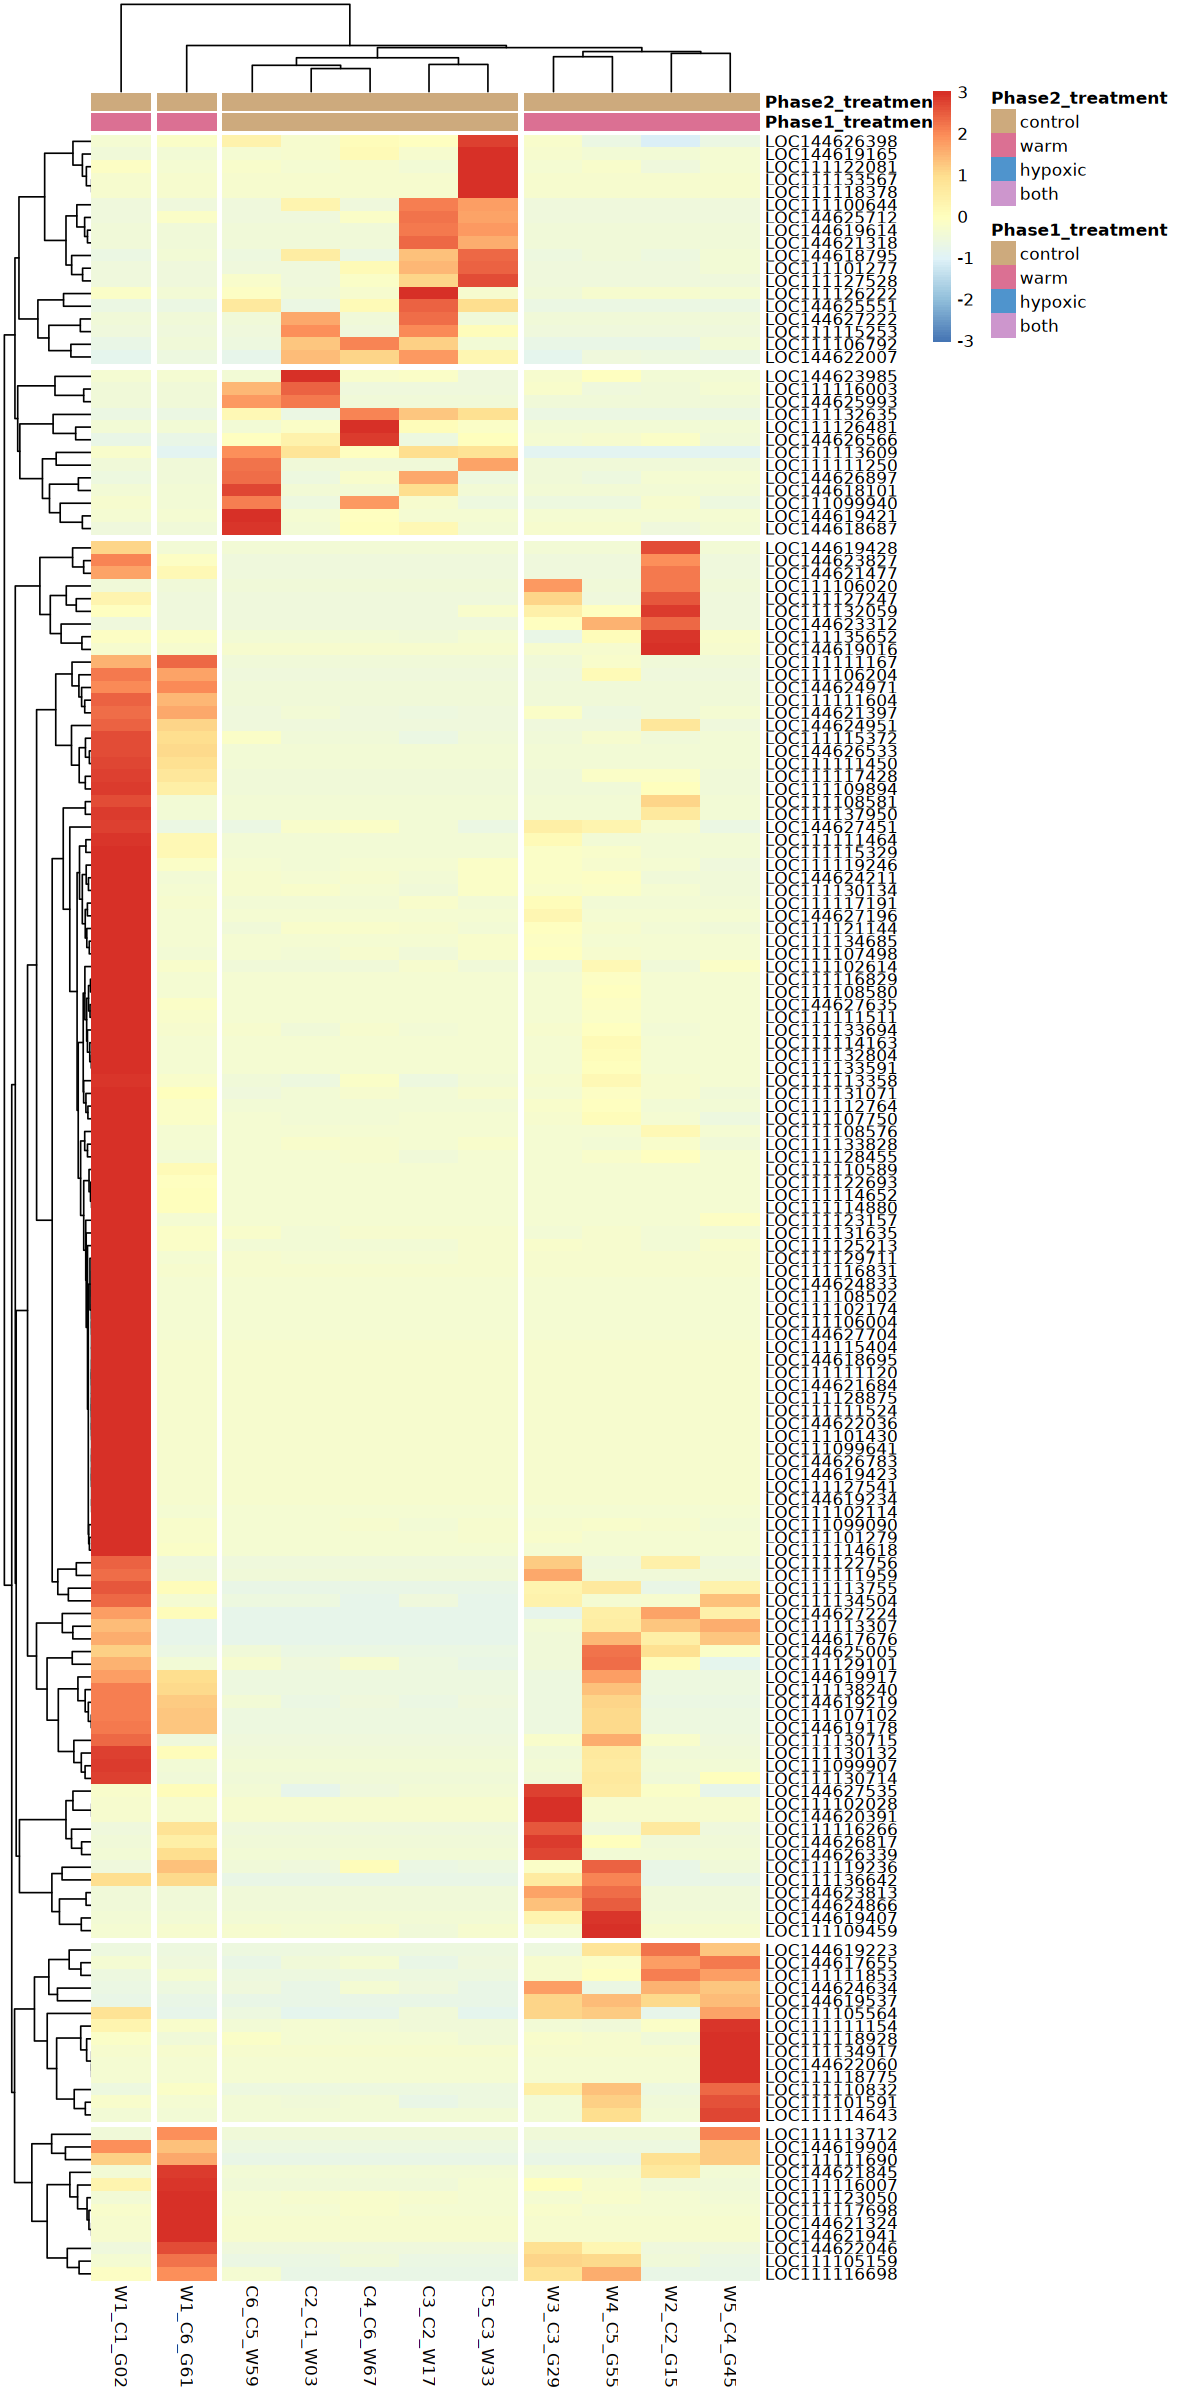

In [134]:
options(repr.plot.height = 20, repr.plot.width = 10)

pheatmap(cc_wc_vst,
         # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 5, 
         cutree_cols = 4,
        scale = 'row' # standardizes each gene separately across samples
        ) 

**CC vs. HC**

In [135]:
cc_hc_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase1_treatment = c("hypoxic", "control"),
  phase2_treatment = "control",
  deg_column = "hc_cc"
)
head(cc_hc_vst)

,C2_C1_W03,C3_C2_W17,C4_C6_W67,C5_C3_W33,C6_C5_W59,H1_C6_B62,H2_C1_B04,H3_C5_B54,H5_C2_B22,H5_C4_B46,H6_C3_B36
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111105564,8.592165,9.098053,8.702947,8.623544,8.906568,12.040039,11.201422,8.720419,10.988910,11.189110,8.594354
LOC144622036,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,9.765951
LOC144619234,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.850083
LOC144622046,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,9.080107,8.765622
LOC111105159,8.483578,8.483578,8.549778,8.483578,8.483578,8.592593,8.483578,8.643354,8.685201,9.817743,9.000520
LOC111138240,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.565946,8.483578,9.060776


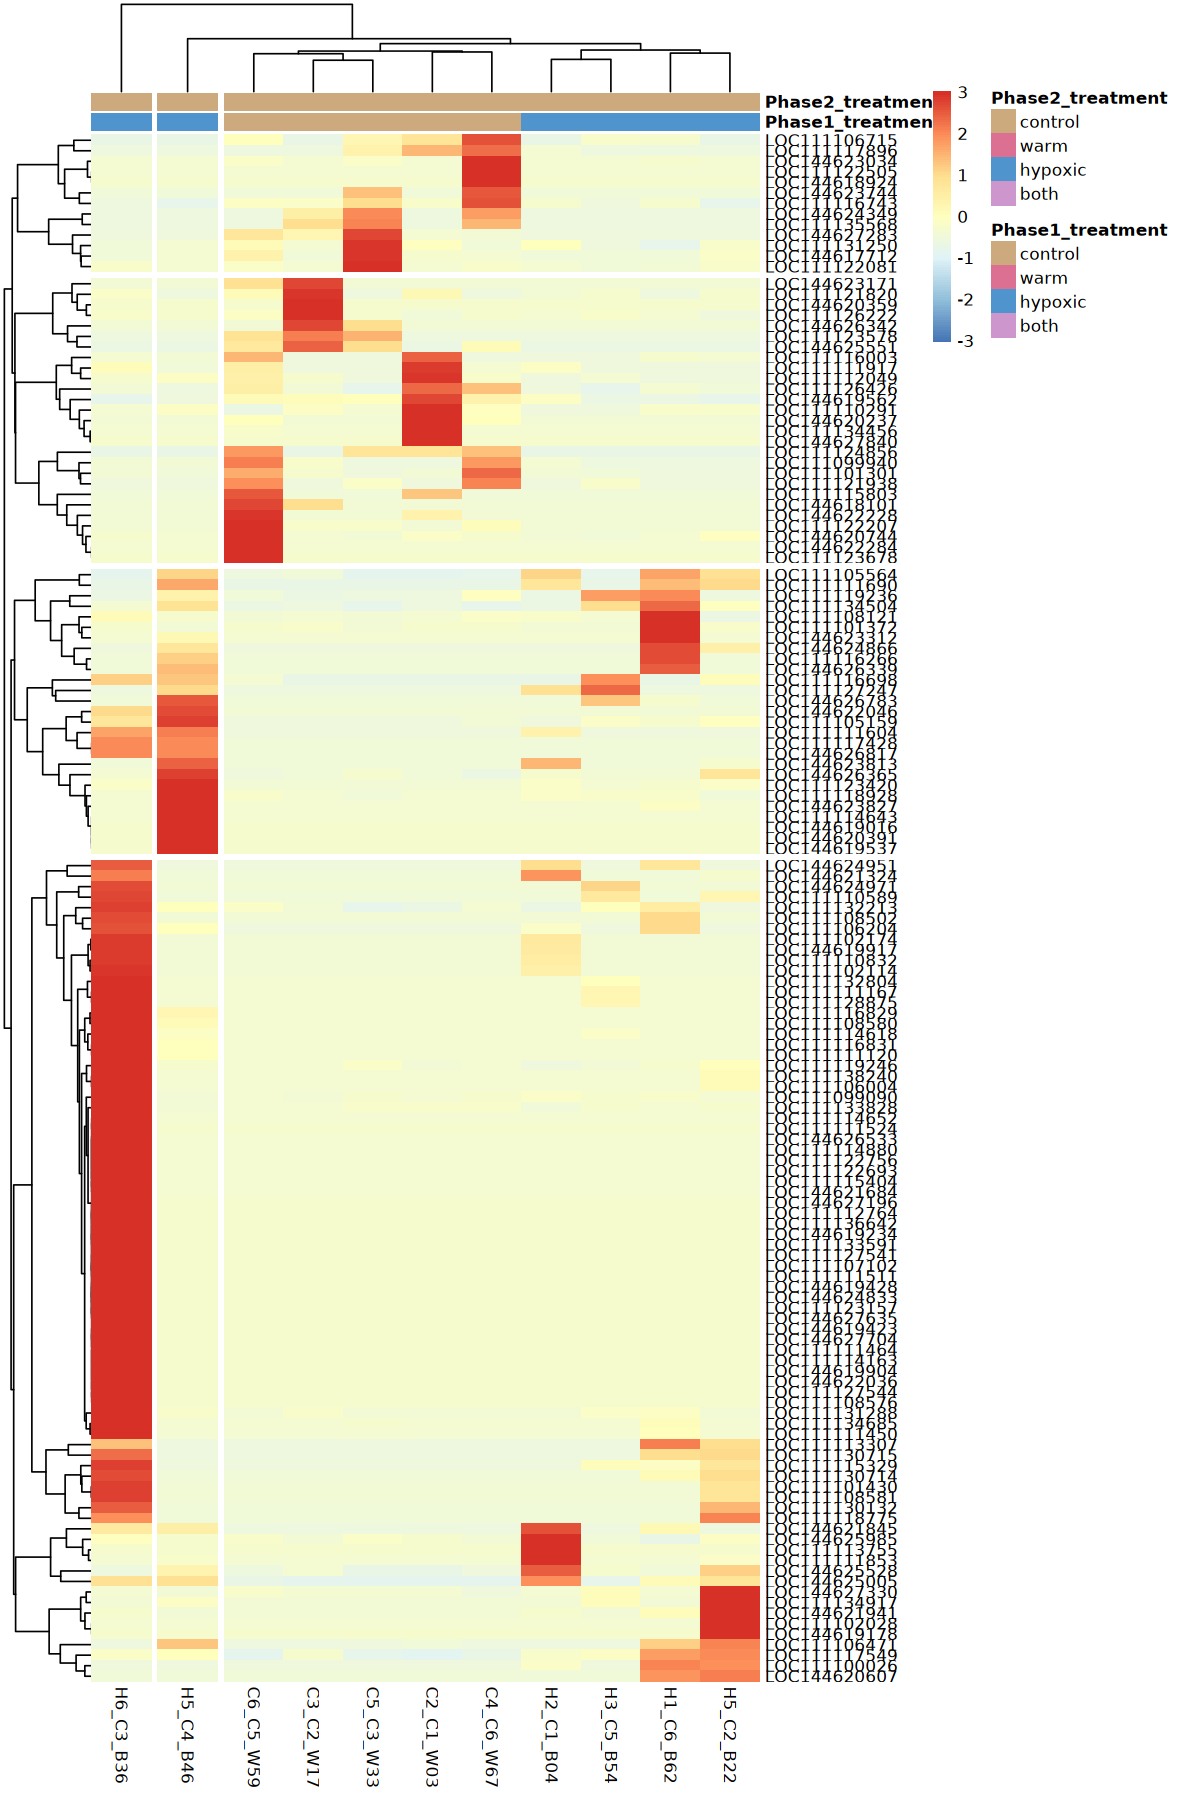

In [136]:
options(repr.plot.height = 15, repr.plot.width = 10)

pheatmap(cc_hc_vst,
         #cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 4, 
         cutree_cols = 3,
        scale = 'row' # standardizes each gene separately across samples
        ) 

**CC vs. BC**

In [137]:
cc_bc_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase1_treatment = c("both", "control"),
  phase2_treatment = "control",
  deg_column = "bc_cc"
)

head(cc_bc_vst)

,B2_C4_O40,B3_C3_O30,B3_C6_O66,B4_C5_O56,B6_C2_O24,C2_C1_W03,C3_C2_W17,C4_C6_W67,C5_C3_W33,C6_C5_W59
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144618596,9.416087,9.901165,9.797846,9.559770,9.747183,8.873994,9.139217,8.884996,9.000025,8.906568
LOC111105564,8.685132,9.798501,11.180485,11.863180,9.043676,8.592165,9.098053,8.702947,8.623544,8.906568
LOC144622036,8.483578,8.483578,10.442689,8.753628,8.587327,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144619234,8.584417,8.483578,8.545273,8.936935,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144622060,8.483578,8.700895,8.483578,8.561639,8.587327,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144619349,8.483578,8.483578,8.483578,8.483578,8.483578,8.560370,8.483578,8.483578,8.483578,8.599803


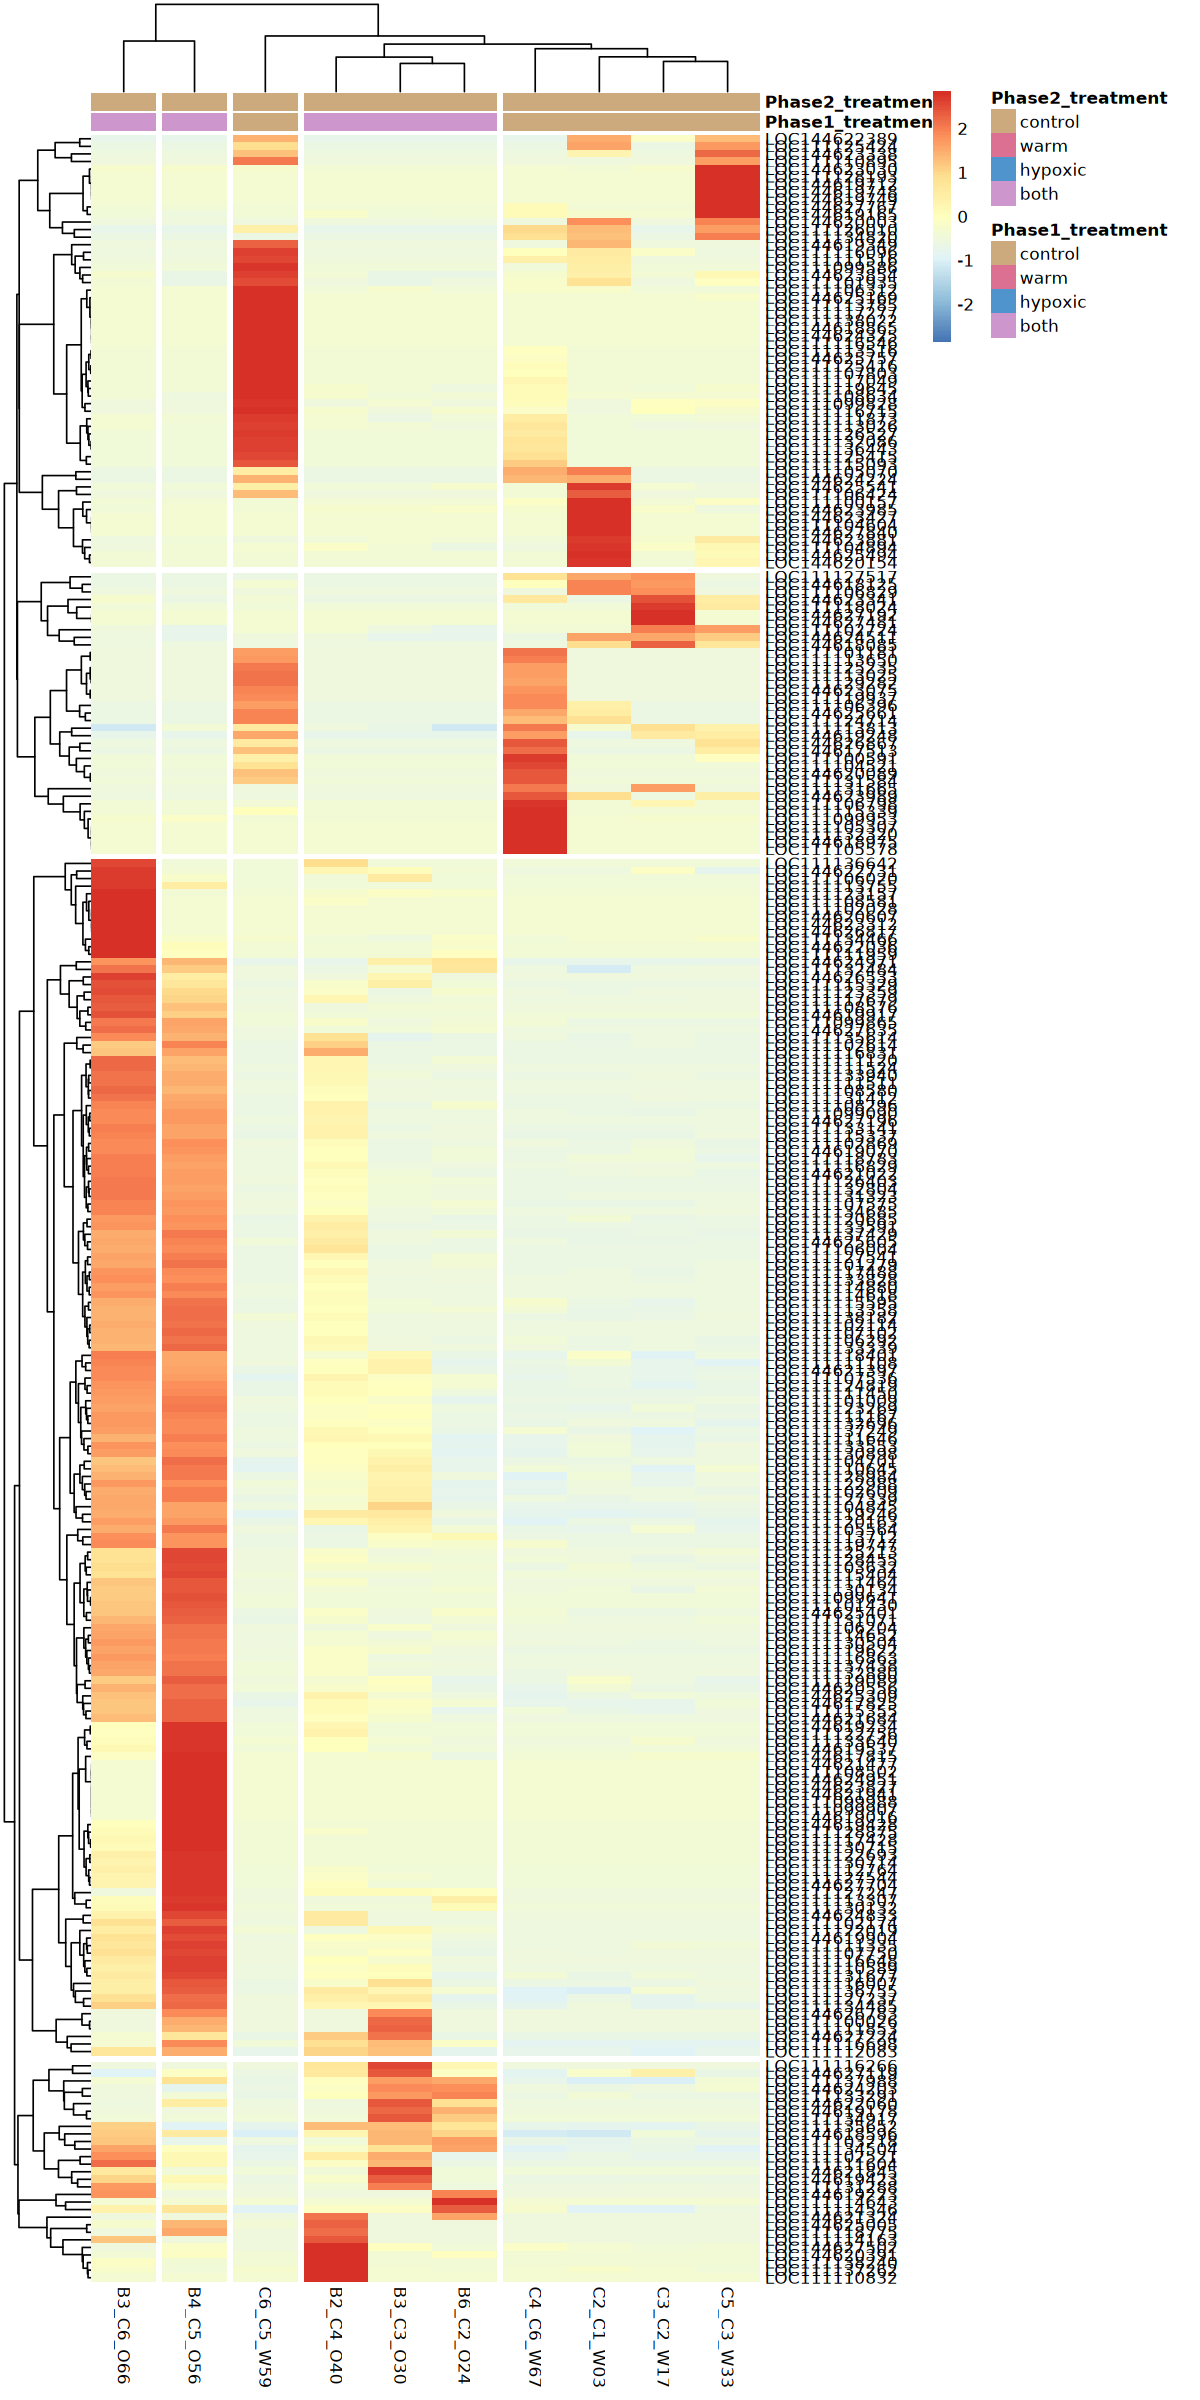

In [138]:
options(repr.plot.height = 20, repr.plot.width = 10)

pheatmap(cc_bc_vst,
         # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 4, 
         cutree_cols = 5,
        scale = 'row' # standardizes each gene separately across samples
        ) 

### 2. effect of single exposure experienced only later in life
- CC vs. CW
- CC vs. CH
- CC vs. CB

**CC vs. CW**

In [139]:
cc_cw_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase2_treatment = c("warm", "control"),
  phase1_treatment = "control",
  deg_column = "cw_cc"
)

head(cc_cw_vst)

,C_W5_W52,C2_C1_W03,C2_W2_W15,C3_C2_W17,C3_W3_W29,C4_C6_W67,C5_C3_W33,C5_W1_W09,C5_W4_W45,C6_C5_W59,C6_W6_W72
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111104592,8.483578,8.978867,11.995245,8.677834,11.774725,8.670705,8.654967,8.592700,11.439466,9.033728,10.274161
LOC111105192,8.770415,8.726157,8.929239,8.737782,9.873568,8.868479,8.693424,8.969403,8.843987,8.661050,8.857872
LOC111102394,8.483578,8.483578,9.147720,8.483578,10.194037,8.483578,8.483578,8.483578,8.641204,8.550693,8.748614
LOC144622036,8.588466,8.483578,8.794530,8.483578,9.711234,8.483578,8.483578,8.483578,8.483578,8.483578,8.947617
LOC144619234,8.557753,8.483578,9.657561,8.483578,8.804882,8.483578,8.483578,8.483578,8.659788,8.483578,8.560186
LOC144622046,9.245620,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578


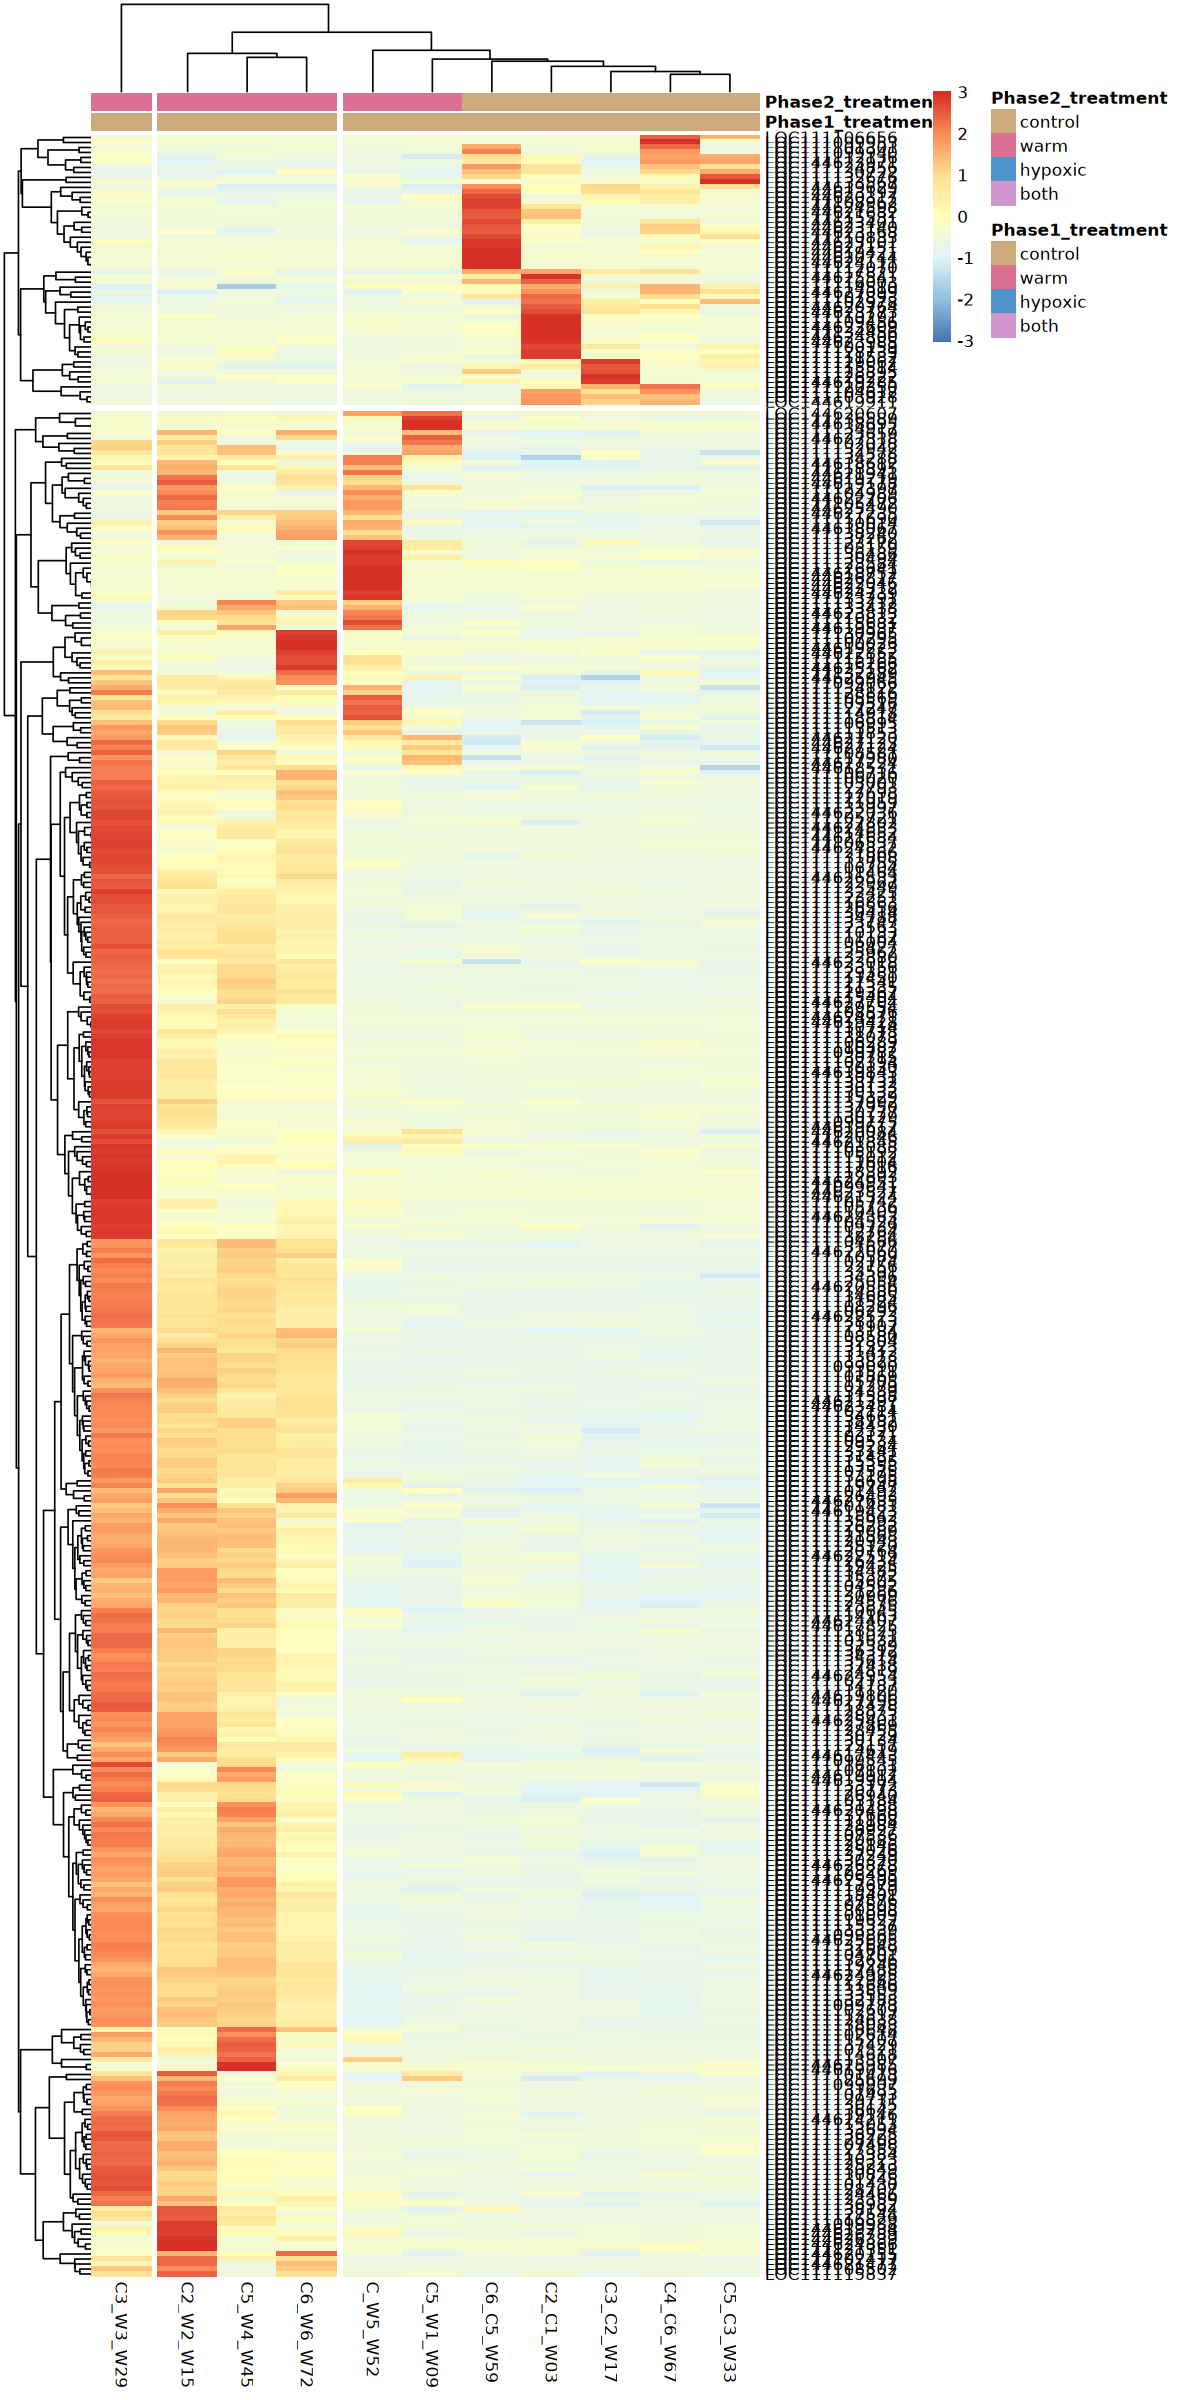

In [146]:
options(repr.plot.height = 20, repr.plot.width = 10)

pheatmap(cc_cw_vst,
        # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 2, 
         cutree_cols = 3,
         scale = 'row'
        ) 

**CC vs. HC**

In [141]:
cc_ch_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase2_treatment = c("hypoxic", "control"),
  phase1_treatment = "control",
  deg_column = "ch_cc"
)

head(cc_ch_vst)

,C1_H2_W13,C1_H6_W62,C2_C1_W03,C2_H1_W04,C3_C2_W17,C4_C6_W67,C4_H5_W56,C5_C3_W33,C6_C5_W59,C6_H3_W36,C6_H4_W48
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC111104083,9.524221,9.908569,9.985081,9.751138,11.833691,9.569543,9.667288,9.720947,10.315941,9.640450,9.341166
LOC144622036,8.483578,8.483578,8.483578,9.014856,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144619234,8.483578,8.483578,8.483578,8.642790,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144622060,8.483578,8.958151,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578
LOC111138240,8.542378,8.483578,8.483578,8.965801,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144619407,8.483578,8.843011,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578


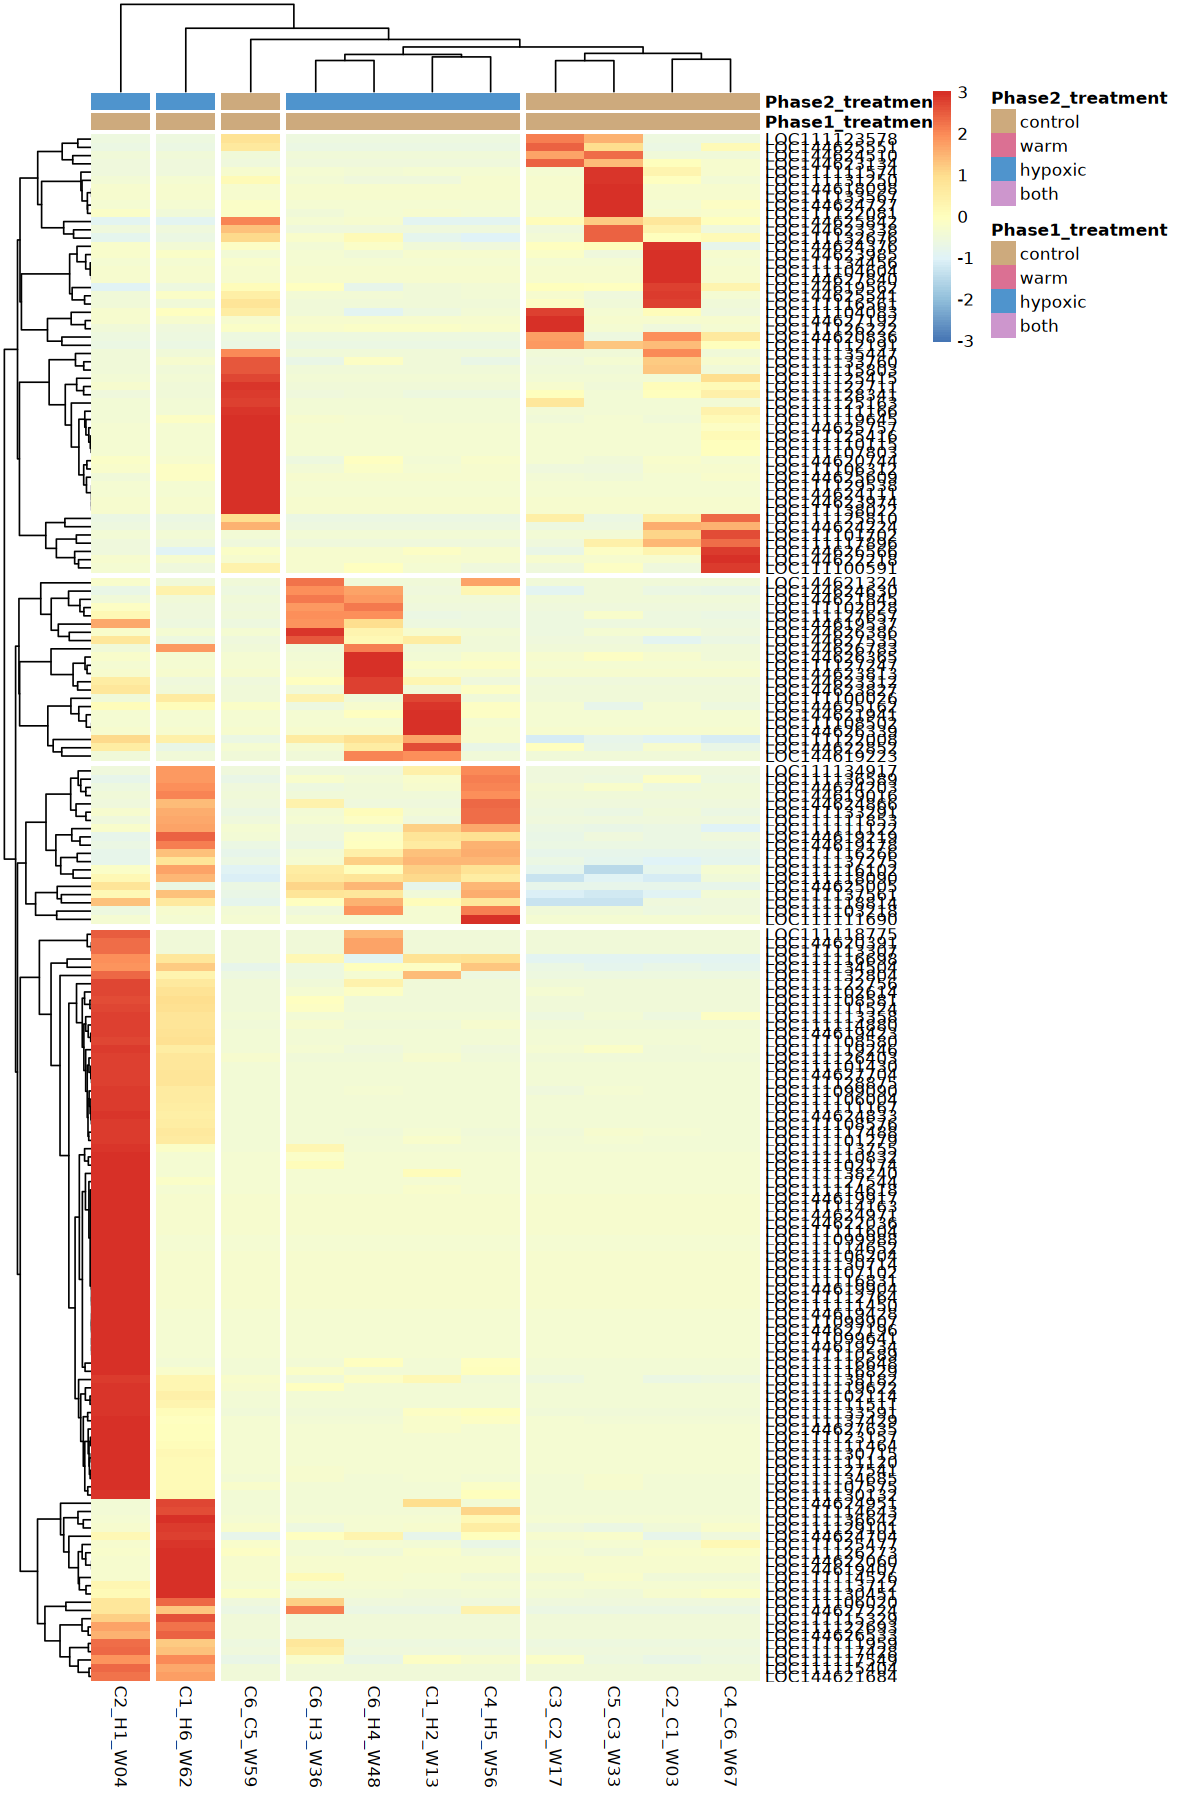

In [147]:
options(repr.plot.height = 15, repr.plot.width = 10)

pheatmap(cc_ch_vst,
        # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 4, 
         cutree_cols = 5,
         scale = 'row'
        ) 

**CC vs. BC**

In [143]:
cc_cb_vst <- get_vst_subset(
  vst = vst,
  meta = meta,
  deg_list = deg_list,
  phase2_treatment = c("both", "control"),
  phase1_treatment = "control",
  deg_column = "cb_cc"
)

head(cc_cb_vst)

,C2_B2_W16,C2_C1_W03,C3_B3_W30,C3_C2_W17,C4_B1_W07,C4_B5_W56,C4_C6_W67,C5_B4_W46,C5_C3_W33,C6_B6_W71,C6_C5_W59
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
LOC144619155,8.561521,10.647179,8.564803,8.803204,8.591453,8.483578,9.367736,8.483578,8.483578,8.483578,8.578484
LOC111104083,9.954515,9.985081,9.417994,11.833691,9.531282,9.655666,9.569543,9.832482,9.720947,9.661966,10.315941
LOC144622036,8.483578,8.483578,8.483578,8.483578,8.823998,8.718735,8.483578,8.595526,8.483578,8.991484,8.483578
LOC144619234,8.483578,8.483578,8.483578,8.483578,8.559866,8.696329,8.483578,8.483578,8.483578,8.483578,8.483578
LOC144622046,8.483578,8.483578,8.888425,8.483578,9.256126,8.483578,8.483578,8.483578,8.483578,8.483578,8.483578
LOC111105159,8.483578,8.483578,9.440750,8.483578,10.225859,8.483578,8.549778,8.483578,8.483578,8.613912,8.483578


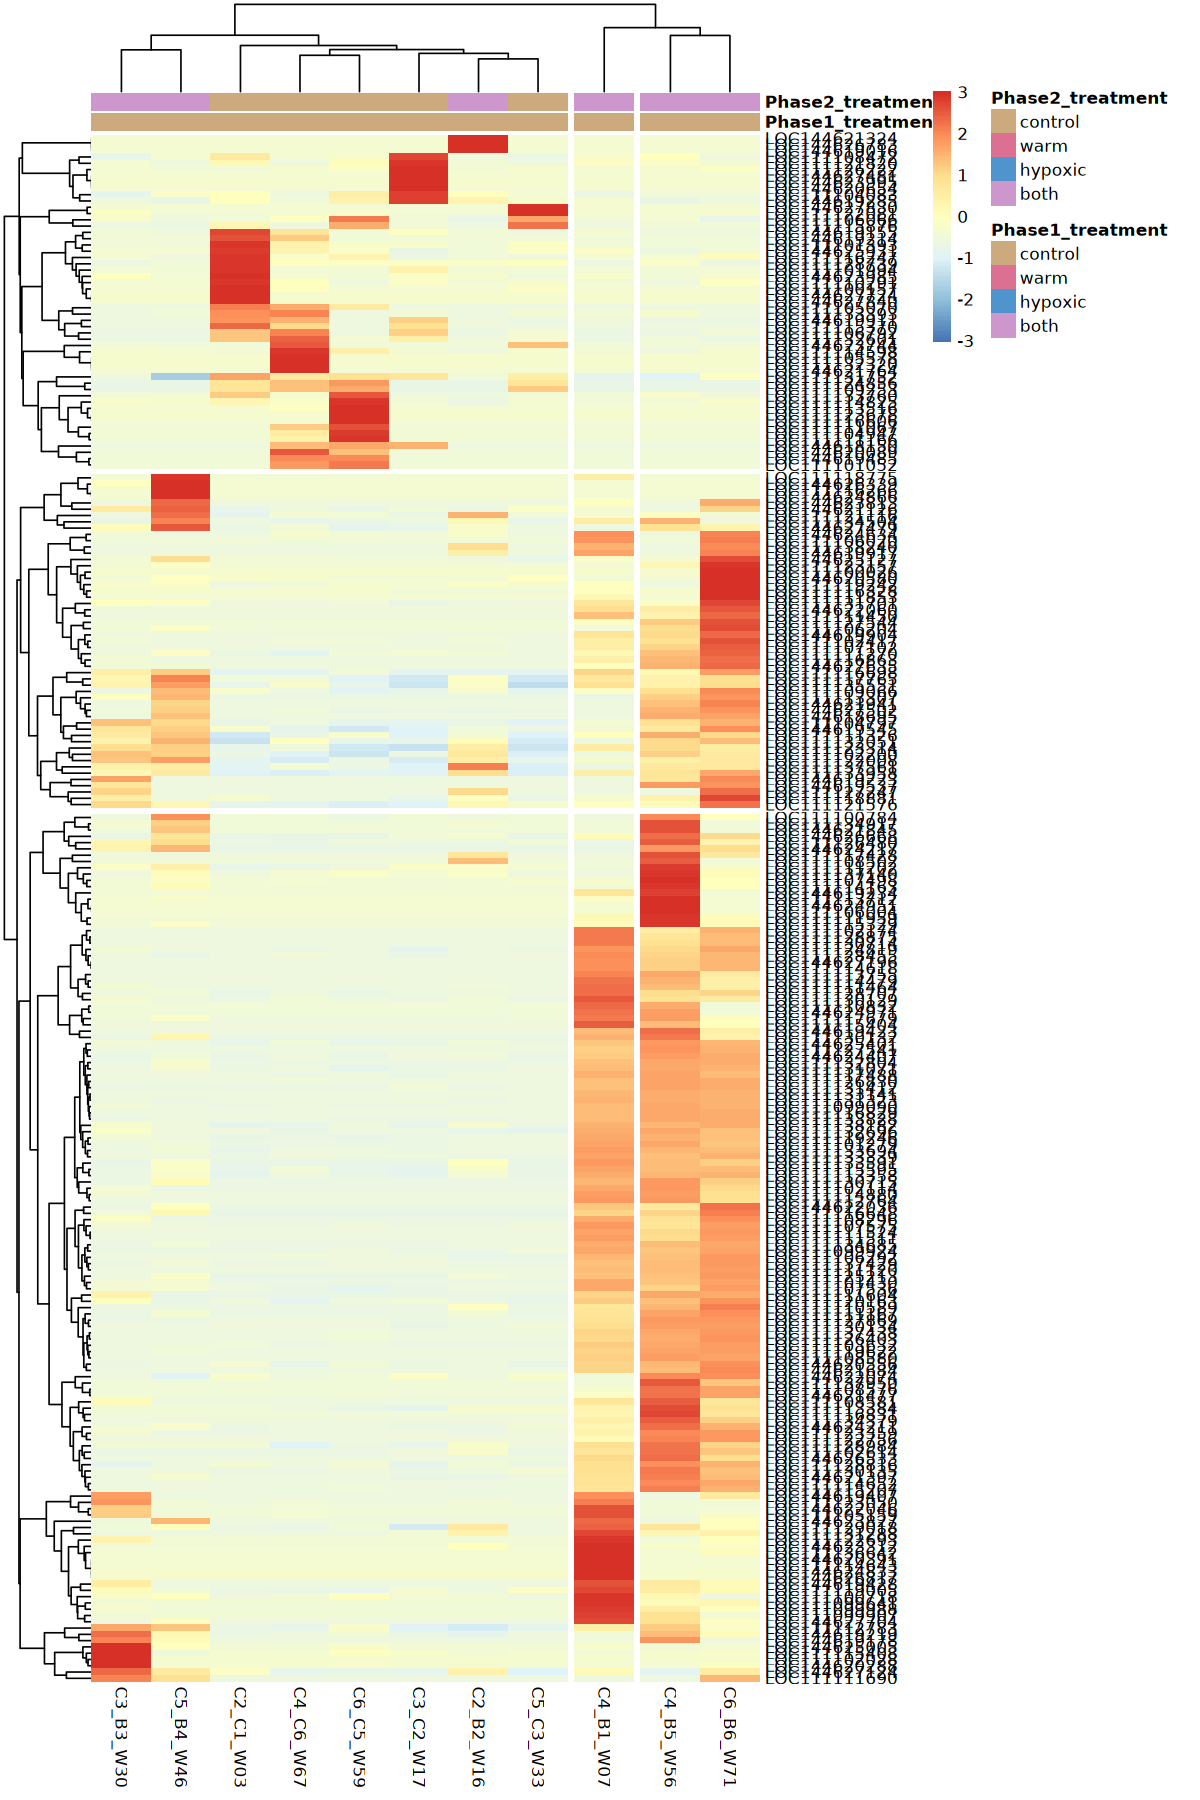

In [150]:
options(repr.plot.height = 15, repr.plot.width = 10)

pheatmap(cc_cb_vst,
        # cluster_cols = FALSE,
        annotation_col = annotation,
         annotation_colors = annotation_colors,
         cutree_rows = 3, 
         cutree_cols = 3,
         scale = 'row'
        ) 

this looks more convincing, at least for the genes with higher expression in the BC samples in the upper left (see more consistent coloring across multiple samples)